# Avalon Deception Dataset: Public History Augmentation

This notebook implements algorithmic augmentation of the Avalon deception dataset, generating multi-round game histories with strategic team selection and voting logic.

## Key Features:
- **Smart Team Selection**: Outcome-dependent team composition with suspicion tracking
- **Strategic Voting**: Realistic voting patterns based on player roles and game state  
- **Multi-Round Generation**: Expands 250 seed games to ~1000 rows with Rounds 2-5
- **Constraint Satisfaction**: Ensures game outcomes match predefined sequences

## 1. Load and Explore the Dataset

In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import random
import re
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("📚 Libraries imported successfully!")
print(f"Using pandas {pd.__version__}, numpy {np.__version__}")

📚 Libraries imported successfully!
Using pandas 2.3.1, numpy 2.2.6


In [22]:
# Load the dataset
print("📥 Loading Deception-Dataset.csv...")
df = pd.read_csv('Deception-Dataset.csv')

print(f"📊 Dataset loaded with {len(df)} rows and {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

# Display basic info
print("\n🔍 Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Game IDs range: {df['game_id'].min()} to {df['game_id'].max()}")
print(f"Round IDs range: {df['round_id'].min()} to {df['round_id'].max()}")
print(f"Unique games: {df['game_id'].nunique()}")

# Show sample rows
print("\n📋 First 3 rows:")
display(df.head(3))

📥 Loading Deception-Dataset.csv...
📊 Dataset loaded with 1000 rows and 12 columns
Columns: ['game_id', 'round_id', 'role_id', 'llm_alignment', 'player_roles', 'public_history', 'prior_summary_gold', 'discussion_log', 'matrix_tactic_scale', 'reasoning_gold', 'Overall_with_formula', 'Overall']

🔍 Dataset Info:
Shape: (1000, 12)
Game IDs range: G001 to G250
Round IDs range: 1 to 5
Unique games: 250

📋 First 3 rows:


,game_id,round_id,role_id,llm_alignment,player_roles,public_history,prior_summary_gold,discussion_log,matrix_tactic_scale,reasoning_gold,Overall_with_formula,Overall
0,G001,1,P1,Good,"{""P1"":""Good"",\n ""P2"":""Good"",\n ""P3"":""Evil"",\n ...","Round: 1\nLeader: P4\nTeam: P4, P5\nVotes: P1:...","""""","Discussion after Quest 1:\n\nP3: ""I think that...","{\n ""P3"": {""row"":""Selective/Framing"",""col"":""O...","{\n ""abduction"": [\n {""player"": ""P2"", ""good...","{\n ""game_id"": ""G001"",\n ""round_id"": 1,\n ""...","{\n ""game_id"": ""G001"",\n ""round_id"": 1,\n ""..."
1,G002,1,P1,Good,"{""P1"":""Good"",\n ""P2"":""Good"",\n ""P3"":""Good"",\n ...","Round: 1\nLeader: P4\nTeam: P4, P5\nVotes: P1:...","""""","Discussion after Quest 1:\r\n\r\nP3: ""P4 and P...","{\n ""P3"": {""row"":""Transparent"",""col"":""Coopera...","{\n ""abduction"": [\n {""player"": ""P3"", ""go...","{\n ""game_id"": ""G002"",\n ""round_id"": 1,\n ""...","{\n ""game_id"": ""G002"",\n ""round_id"": 1,\n ""..."
2,G003,1,P1,Good,"{""P1"":""Good"",\n ""P2"":""Good"",\n ""P3"":""Good"",\n ...","Round: 1\nLeader: P4\nTeam: P4, P5\nVotes: P1:...","""""","Discussion after Quest 1:\n\nP4: ""Maybe it's P...","{\n ""P4"": {""row"":""Selective/Framing"",""col"":""D...","{\n ""abduction"": [\n {""player"": ""P4"", ""go...","{\n ""game_id"": ""G003"",\n ""round_id"": 1,\n ""...","{\n ""game_id"": ""G003"",\n ""round_id"": 1,\n ""..."


## 2. Extract Game Configuration Information

In [23]:
# Define game constants
PLAYERS = ['P1', 'P2', 'P3', 'P4', 'P5']
TEAM_SIZES = {1: 2, 2: 3, 3: 2, 4: 3, 5: 3}  # Corrected team sizes

# Define outcome sequences based on your constraints
SEQ_R3_FAIL = ['FAIL', 'FAIL', 'FAIL']
SEQ_R3_PASS = ['PASS', 'PASS', 'PASS']

# Round 4 sequences
SEQ_R4_LOSE = [
    ['FAIL','PASS','FAIL','FAIL'],  # FPFF
    ['FAIL','FAIL','PASS','FAIL'],  # FFPF  
    ['PASS','FAIL','FAIL','FAIL']   # PFFF
]

SEQ_R4_WIN = [
    ['PASS','FAIL','PASS','PASS'],  # PFPP
    ['PASS','PASS','FAIL','PASS'],  # PPFP
    ['FAIL','PASS','PASS','PASS']   # FPPP
]

# Round 5 sequences  
SEQ_R5_LOSE = [
    ['FAIL','PASS','PASS','FAIL','FAIL'],  # FPPFF
    ['FAIL','FAIL','PASS','PASS','FAIL'],  # FFPPF
    ['FAIL','PASS','FAIL','PASS','FAIL'],  # FPFPF
    ['PASS','PASS','FAIL','FAIL','FAIL'],  # PPFFF
    ['PASS','FAIL','PASS','FAIL','FAIL'],  # PFPFF
    ['PASS','FAIL','FAIL','PASS','FAIL']   # PFFPF
]

SEQ_R5_WIN = [
    ['PASS','FAIL','FAIL','PASS','PASS'],  # PFFPP
    ['PASS','PASS','FAIL','FAIL','PASS'],  # PPFFP
    ['PASS','FAIL','PASS','FAIL','PASS'],  # PFPFP
    ['FAIL','FAIL','PASS','PASS','PASS'],  # FFPPP
    ['FAIL','PASS','FAIL','PASS','PASS'],  # FPFPP
    ['FAIL','PASS','PASS','FAIL','PASS']   # FPPFP
]

print("🎯 Game constants defined:")
print(f"Players: {PLAYERS}")
print(f"Team sizes by round: {TEAM_SIZES}")
print(f"Total outcome sequences: R3({len([SEQ_R3_FAIL, SEQ_R3_PASS])}), R4({len(SEQ_R4_LOSE + SEQ_R4_WIN)}), R5({len(SEQ_R5_LOSE + SEQ_R5_WIN)})")

🎯 Game constants defined:
Players: ['P1', 'P2', 'P3', 'P4', 'P5']
Team sizes by round: {1: 2, 2: 3, 3: 2, 4: 3, 5: 3}
Total outcome sequences: R3(2), R4(6), R5(12)


In [24]:
# Balanced sequence selection with cycling
def get_balanced_sequence_index(gid, sequence_list, game_ranges):
    """
    Get balanced sequence index by cycling through sequences sequentially
    within each game range to ensure equal distribution.
    """
    # Find which range this game belongs to and its position within that range
    for range_start, range_end in game_ranges:
        if range_start <= gid <= range_end:
            position_in_range = gid - range_start
            sequence_index = position_in_range % len(sequence_list)
            return sequence_index
    
    # Fallback to cycling based on game ID
    return gid % len(sequence_list)

# Function to determine game sequence based on game ID (BALANCED)
def get_game_sequence(gid):
    """
    Determine the outcome sequence for a game based on your constraints.
    Uses sequential cycling for balanced distribution of sequences.
    Returns the sequence of outcomes for each round.
    """
    # Round 3 endings (3 rounds total)
    if (1 <= gid <= 20):
        return SEQ_R3_FAIL
    if (51 <= gid <= 60) or (101 <= gid <= 110) or (151 <= gid <= 160) or (201 <= gid <= 210):
        return SEQ_R3_FAIL  
    if (61 <= gid <= 70) or (111 <= gid <= 120) or (161 <= gid <= 170) or (211 <= gid <= 220):
        return SEQ_R3_PASS
    
    # Round 4 endings (4 rounds total) - BALANCED CYCLING
    r4_lose_ranges = [(21, 25), (71, 75), (121, 125), (171, 175), (221, 225)]
    if any(start <= gid <= end for start, end in r4_lose_ranges):
        seq_idx = get_balanced_sequence_index(gid, SEQ_R4_LOSE, r4_lose_ranges)
        return SEQ_R4_LOSE[seq_idx]
    
    r4_win_ranges = [(26, 30), (76, 80), (126, 130), (176, 180), (226, 230)]
    if any(start <= gid <= end for start, end in r4_win_ranges):
        seq_idx = get_balanced_sequence_index(gid, SEQ_R4_WIN, r4_win_ranges)
        return SEQ_R4_WIN[seq_idx]
    
    # Round 5 endings (5 rounds total) - BALANCED CYCLING
    r5_lose_ranges = [(31, 40), (81, 90), (131, 140), (181, 190), (231, 240)]
    if any(start <= gid <= end for start, end in r5_lose_ranges):
        seq_idx = get_balanced_sequence_index(gid, SEQ_R5_LOSE, r5_lose_ranges)
        return SEQ_R5_LOSE[seq_idx]
    
    r5_win_ranges = [(41, 50), (91, 100), (141, 150), (191, 200), (241, 250)]
    if any(start <= gid <= end for start, end in r5_win_ranges):
        seq_idx = get_balanced_sequence_index(gid, SEQ_R5_WIN, r5_win_ranges)
        return SEQ_R5_WIN[seq_idx]
    
    # Fallback - cycle through lose sequences
    return SEQ_R5_LOSE[gid % len(SEQ_R5_LOSE)]

# Function for leader rotation
def get_next_leader(current_leader):
    """Rotate to next leader: P1->P2->P3->P4->P5->P1"""
    idx = int(current_leader[1]) - 1
    return f"P{(idx + 1) % 5 + 1}"

# Test balanced sequence distribution
def test_balanced_distribution():
    """Test that sequences are distributed evenly across game ranges"""
    
    print("🧪 Testing balanced sequence distribution:")
    
    # Test R4 LOSE sequences (should cycle through 3 sequences)
    r4_lose_games = list(range(21, 26))  # G21-G25
    r4_lose_sequences = [get_game_sequence(gid) for gid in r4_lose_games]
    
    print(f"\nR4 LOSE (G21-25):")
    for i, (gid, seq) in enumerate(zip(r4_lose_games, r4_lose_sequences)):
        seq_str = ''.join(seq)
        print(f"  G{gid:03d}: {seq_str} (sequence #{i % 3})")
    
    # Test R5 LOSE sequences (should cycle through 6 sequences) 
    r5_lose_games = list(range(31, 41))  # G31-G40
    r5_lose_sequences = [get_game_sequence(gid) for gid in r5_lose_games]
    
    print(f"\nR5 LOSE (G31-40):")
    for i, (gid, seq) in enumerate(zip(r5_lose_games, r5_lose_sequences)):
        seq_str = ''.join(seq)
        print(f"  G{gid:03d}: {seq_str} (sequence #{i % 6})")
    
    # Verify balance by counting unique sequences
    from collections import Counter
    r4_counts = Counter([''.join(seq) for seq in r4_lose_sequences])
    r5_counts = Counter([''.join(seq) for seq in r5_lose_sequences])
    
    print(f"\n📊 Sequence distribution balance:")
    print(f"R4 LOSE sequences: {dict(r4_counts)}")
    print(f"R5 LOSE sequences: {dict(r5_counts)}")
    
    # Check if balanced (optimal distribution given mathematical constraints)
    # R4: 5 games, 3 sequences -> optimal is 2,2,1 distribution
    # R5: 10 games, 6 sequences -> optimal is 2,2,2,2,1,1 distribution
    r4_values = sorted(r4_counts.values(), reverse=True)
    r5_values = sorted(r5_counts.values(), reverse=True)
    
    # Check if we have optimal balance (max difference of 1)
    r4_balanced = (max(r4_values) - min(r4_values)) <= 1
    r5_balanced = (max(r5_values) - min(r5_values)) <= 1
    
    print(f"✅ R4 balanced: {r4_balanced}")
    print(f"✅ R5 balanced: {r5_balanced}")

# Run the test
test_balanced_distribution()

print(f"\n🔄 Leader rotation test: P1 -> {get_next_leader('P1')} -> {get_next_leader('P2')}")

🧪 Testing balanced sequence distribution:

R4 LOSE (G21-25):
  G021: FAILPASSFAILFAIL (sequence #0)
  G022: FAILFAILPASSFAIL (sequence #1)
  G023: PASSFAILFAILFAIL (sequence #2)
  G024: FAILPASSFAILFAIL (sequence #0)
  G025: FAILFAILPASSFAIL (sequence #1)

R5 LOSE (G31-40):
  G031: FAILPASSPASSFAILFAIL (sequence #0)
  G032: FAILFAILPASSPASSFAIL (sequence #1)
  G033: FAILPASSFAILPASSFAIL (sequence #2)
  G034: PASSPASSFAILFAILFAIL (sequence #3)
  G035: PASSFAILPASSFAILFAIL (sequence #4)
  G036: PASSFAILFAILPASSFAIL (sequence #5)
  G037: FAILPASSPASSFAILFAIL (sequence #0)
  G038: FAILFAILPASSPASSFAIL (sequence #1)
  G039: FAILPASSFAILPASSFAIL (sequence #2)
  G040: PASSPASSFAILFAILFAIL (sequence #3)

📊 Sequence distribution balance:
R4 LOSE sequences: {'FAILPASSFAILFAIL': 2, 'FAILFAILPASSFAIL': 2, 'PASSFAILFAILFAIL': 1}
R5 LOSE sequences: {'FAILPASSPASSFAILFAIL': 2, 'FAILFAILPASSPASSFAIL': 2, 'FAILPASSFAILPASSFAIL': 2, 'PASSPASSFAILFAILFAIL': 2, 'PASSFAILPASSFAILFAIL': 1, 'PASSFAILFAILPASS

## 3. Implement Smart Team Selection Logic

**Refined Strategy:**

**Good Leaders:**
- **PASS missions**: Select any players (good/evil) with lowest suspicion scores
- **FAIL missions**: MUST include at least one evil player for verification/testing strategy

**Evil Leaders:**
- **PASS/FAIL missions**: Flexible selection but avoid highly suspicious players to maintain cover
- Can achieve desired outcome through their own vote regardless of team composition

In [25]:
# Smart team selection function with refined Avalon mechanics
def select_team_smart(leader, target_outcome, roles, round_num, suspicion_scores):
    """
    Intelligently select team based on desired outcome using refined Avalon behavior:
    
    Good Leader:
    - PASS: Select any players (good/evil) with low suspicion
    - FAIL: MUST select at least one evil player (testing/verification strategy)
    
    Evil Leader: 
    - PASS/FAIL: Can select anyone but avoids highly suspicious players (maintain cover)
    
    Args:
        leader: Current leader (e.g., 'P1')
        target_outcome: 'PASS' or 'FAIL'  
        roles: Dict of player roles {player: 'Good'/'Evil'} (ground truth for selection logic)
        round_num: Current round number
        suspicion_scores: Dict of suspicion levels {player: float}
    
    Returns:
        List of players selected for the team
    """
    team_size = TEAM_SIZES[round_num]
    leader_role = roles.get(leader, 'Good')
    
    def get_candidates_by_suspicion(exclude_leader=True):
        """Get players sorted by suspicion (low to high)"""
        candidates = [p for p in PLAYERS if not (exclude_leader and p == leader)]
        return sorted(candidates, key=lambda p: suspicion_scores.get(p, 0))
    
    def select_by_suspicion_threshold(candidates, k, max_suspicion=float('inf')):
        """Select k players from candidates with suspicion below threshold"""
        if not candidates or k <= 0:
            return []
        
        # Filter by suspicion threshold
        eligible = [p for p in candidates if suspicion_scores.get(p, 0) <= max_suspicion]
        if not eligible:
            eligible = candidates  # Fallback if all above threshold
        
        # Take lowest suspicion players
        return eligible[:min(k, len(eligible))]
    
    # Initialize team with leader (always includes self)
    team = [leader]
    remaining_slots = team_size - 1
    
    if leader_role == 'Good':
        # Good leader behavior based on target outcome
        
        if target_outcome == 'PASS':
            # Good leader wants success: pick most trusted players (lowest suspicion)
            candidates = get_candidates_by_suspicion(exclude_leader=True)
            selected = select_by_suspicion_threshold(candidates, remaining_slots)
            team.extend(selected)
            
        else:  # target_outcome == 'FAIL'
            # Good leader MUST include evil player for verification/testing
            # Strategy: "I suspect this player might be evil, let me test them on a mission"
            
            # Get evil players sorted by suspicion (lowest first)
            evil_players = [p for p in PLAYERS if p != leader and roles.get(p) == 'Evil']
            evil_by_suspicion = sorted(evil_players, key=lambda p: suspicion_scores.get(p, 0))
            
            if evil_by_suspicion:
                # Always pick at least one evil player (the least suspicious one)
                chosen_evil = evil_by_suspicion[0]
                team.append(chosen_evil)
                remaining_slots -= 1
                
                # Fill remaining slots with lowest suspicion players (good or evil)
                if remaining_slots > 0:
                    candidates = [p for p in PLAYERS if p not in team]
                    candidates_by_suspicion = sorted(candidates, key=lambda p: suspicion_scores.get(p, 0))
                    selected = select_by_suspicion_threshold(candidates_by_suspicion, remaining_slots)
                    team.extend(selected)
            else:
                # No evil players available (shouldn't happen in normal game)
                candidates = get_candidates_by_suspicion(exclude_leader=True)
                selected = select_by_suspicion_threshold(candidates, remaining_slots)
                team.extend(selected)
                
    else:  # Evil leader
        # Evil leader behavior: Flexible selection while maintaining cover
        # Can achieve any outcome through their own voting behavior
        
        # Avoid highly suspicious players to maintain cover
        # Use dynamic threshold based on overall suspicion levels
        all_suspicions = [suspicion_scores.get(p, 0) for p in PLAYERS if p != leader]
        if all_suspicions:
            avg_suspicion = sum(all_suspicions) / len(all_suspicions)
            max_suspicion = avg_suspicion + 1.0  # Allow slightly above average
        else:
            max_suspicion = 1.5  # Default threshold
        
        candidates = get_candidates_by_suspicion(exclude_leader=True)
        
        # Filter out highly suspicious players
        safe_candidates = [p for p in candidates if suspicion_scores.get(p, 0) <= max_suspicion]
        if not safe_candidates:
            safe_candidates = candidates[:min(3, len(candidates))]  # Take least suspicious if all are high
        
        selected = select_by_suspicion_threshold(safe_candidates, remaining_slots, max_suspicion)
        team.extend(selected)
    
    # Ensure team size is correct
    while len(team) < team_size:
        available = [p for p in PLAYERS if p not in team]
        if available:
            # Add least suspicious available player
            available_by_suspicion = sorted(available, key=lambda p: suspicion_scores.get(p, 0))
            team.append(available_by_suspicion[0])
        else:
            break
    
    return sorted(team[:team_size])

# Test the refined function
print("🧪 Testing refined smart team selection with your improved logic:")
test_roles = {'P1': 'Good', 'P2': 'Good', 'P3': 'Evil', 'P4': 'Evil', 'P5': 'Good'}

# Test different suspicion scenarios
print("\n=== Scenario 1: P3 (Evil) has low suspicion ===")
test_suspicion1 = {'P1': 0.5, 'P2': 1.2, 'P3': 0.1, 'P4': 2.1, 'P5': 0.8}
print(f"Suspicion: {test_suspicion1}")

test_scenarios1 = [
    ('P1', 'Good', 'PASS'), ('P1', 'Good', 'FAIL'),
    ('P3', 'Evil', 'PASS'), ('P3', 'Evil', 'FAIL'),
]

for leader, leader_role, outcome in test_scenarios1:
    team = select_team_smart(leader, outcome, test_roles, 3, test_suspicion1)
    team_roles = [test_roles[p] for p in team]
    evil_count = team_roles.count('Evil')
    
    print(f"{leader_role} leader {leader} → {outcome}: {team} ({team_roles}) [Evil: {evil_count}]")

print("\n=== Scenario 2: All evil players have high suspicion ===")
test_suspicion2 = {'P1': 0.3, 'P2': 0.4, 'P3': 2.5, 'P4': 2.8, 'P5': 0.2}
print(f"Suspicion: {test_suspicion2}")

for leader, leader_role, outcome in [('P1', 'Good', 'FAIL')]:
    team = select_team_smart(leader, outcome, test_roles, 3, test_suspicion2)
    team_roles = [test_roles[p] for p in team]
    evil_count = team_roles.count('Evil')
    
    print(f"{leader_role} leader {leader} → {outcome}: {team} ({team_roles}) [Evil: {evil_count}]")
    print("  Rationale: Good leader tests highly suspicious P3 to verify if evil")

print("\n=== Scenario 3: Evil leader with mixed suspicions ===")
test_suspicion3 = {'P1': 1.8, 'P2': 0.4, 'P3': 0.2, 'P4': 1.2, 'P5': 0.6}
print(f"Suspicion: {test_suspicion3}")

for leader, leader_role, outcome in [('P3', 'Evil', 'PASS'), ('P3', 'Evil', 'FAIL')]:
    team = select_team_smart(leader, outcome, test_roles, 3, test_suspicion3)
    team_roles = [test_roles[p] for p in team]
    evil_count = team_roles.count('Evil')
    
    print(f"{leader_role} leader {leader} → {outcome}: {team} ({team_roles}) [Evil: {evil_count}]")
    print(f"  Avoids P1 (suspicion: 1.8) to maintain cover")

print("\n✅ Your logic ensures:")
print("  - Good leaders targeting FAIL always include evil players (testing strategy)")
print("  - Evil leaders avoid highly suspicious players (maintain cover)")
print("  - All selections are realistic and constraint-satisfying")

🧪 Testing refined smart team selection with your improved logic:

=== Scenario 1: P3 (Evil) has low suspicion ===
Suspicion: {'P1': 0.5, 'P2': 1.2, 'P3': 0.1, 'P4': 2.1, 'P5': 0.8}
Good leader P1 → PASS: ['P1', 'P3'] (['Good', 'Evil']) [Evil: 1]
Good leader P1 → FAIL: ['P1', 'P3'] (['Good', 'Evil']) [Evil: 1]
Evil leader P3 → PASS: ['P1', 'P3'] (['Good', 'Evil']) [Evil: 1]
Evil leader P3 → FAIL: ['P1', 'P3'] (['Good', 'Evil']) [Evil: 1]

=== Scenario 2: All evil players have high suspicion ===
Suspicion: {'P1': 0.3, 'P2': 0.4, 'P3': 2.5, 'P4': 2.8, 'P5': 0.2}
Good leader P1 → FAIL: ['P1', 'P3'] (['Good', 'Evil']) [Evil: 1]
  Rationale: Good leader tests highly suspicious P3 to verify if evil

=== Scenario 3: Evil leader with mixed suspicions ===
Suspicion: {'P1': 1.8, 'P2': 0.4, 'P3': 0.2, 'P4': 1.2, 'P5': 0.6}
Evil leader P3 → PASS: ['P2', 'P3'] (['Good', 'Evil']) [Evil: 1]
  Avoids P1 (suspicion: 1.8) to maintain cover
Evil leader P3 → FAIL: ['P2', 'P3'] (['Good', 'Evil']) [Evil: 1]


## 4. Generate Suspicion Scoring System

In [26]:
# Suspicion scoring system
def update_suspicion_scores(suspicion_scores, team, outcome, round_num):
    """
    Update suspicion scores based on mission outcome.
    
    Args:
        suspicion_scores: Current suspicion dict {player: score}
        team: Players who were on the mission
        outcome: 'PASS' or 'FAIL'
        round_num: Current round number
    
    Returns:
        Updated suspicion_scores dict
    """
    # Create copy to avoid modifying original
    new_scores = suspicion_scores.copy()
    
    if outcome == 'FAIL':
        # Increase suspicion for all team members
        for player in team:
            new_scores[player] = new_scores.get(player, 0) + 1.0
            
    else:  # outcome == 'PASS'  
        # Slightly decrease suspicion for team members (they helped succeed)
        for player in team:
            new_scores[player] = max(0, new_scores.get(player, 0) - 0.3)
    
    return new_scores

def initialize_suspicion_scores():
    """Initialize suspicion scores for all players"""
    return {player: 0.0 for player in PLAYERS}

# Test suspicion system
print("🧪 Testing suspicion scoring system:")
suspicion = initialize_suspicion_scores()
print(f"Initial: {suspicion}")

# Simulate failed mission
team1 = ['P1', 'P3', 'P4']
suspicion = update_suspicion_scores(suspicion, team1, 'FAIL', 1)
print(f"After {team1} FAIL: {suspicion}")

# Simulate successful mission  
team2 = ['P2', 'P5']
suspicion = update_suspicion_scores(suspicion, team2, 'PASS', 2)
print(f"After {team2} PASS: {suspicion}")

🧪 Testing suspicion scoring system:
Initial: {'P1': 0.0, 'P2': 0.0, 'P3': 0.0, 'P4': 0.0, 'P5': 0.0}
After ['P1', 'P3', 'P4'] FAIL: {'P1': 1.0, 'P2': 0.0, 'P3': 1.0, 'P4': 1.0, 'P5': 0.0}
After ['P2', 'P5'] PASS: {'P1': 1.0, 'P2': 0, 'P3': 1.0, 'P4': 1.0, 'P5': 0}


## 5. Create Strategic Voting Mechanisms

In [27]:
# Strategic voting system
def generate_strategic_votes(team, roles, suspicion_scores, protagonist_player, is_losing_game):
    """
    Generate strategic voting patterns based on team composition and game state.
    
    Args:
        team: List of players on the proposed team
        roles: Dict of player roles {player: 'Good'/'Evil'}  
        suspicion_scores: Current suspicion levels
        protagonist_player: The POV player (role_id)
        is_losing_game: Boolean indicating if this is a losing game
    
    Returns:
        String formatted as "P1:Y P2:N P3:Y P4:Y P5:Y"
    """
    votes = {player: 'Y' for player in PLAYERS}  # Start with all Yes
    
    # Check if team contains evil players
    team_has_evil = any(roles.get(p) == 'Evil' for p in team)
    
    # Calculate team suspicion level
    team_suspicion = sum(suspicion_scores.get(p, 0) for p in team)
    suspicion_threshold = 2.0  # Threshold for rejection
    
    # Strategic voting logic
    for player in PLAYERS:
        player_role = roles.get(player, 'Good')
        
        if player in team:
            # Team members usually vote Yes (self-interest)
            votes[player] = 'Y'
            continue
            
        if player_role == 'Good':
            # Good players vote strategically
            
            # 1. Protagonist constraint: Vote No if suspicious team in losing games
            if player == protagonist_player and is_losing_game and team_has_evil:
                votes[player] = 'N'
                continue
                
            # 2. High suspicion team gets rejected
            if team_suspicion > suspicion_threshold:
                # Random chance to vote No
                if random.random() < 0.6:  # 60% chance to reject suspicious team
                    votes[player] = 'N'
                continue
                
            # 3. If team has known evil players (high suspicion)
            highly_suspicious = [p for p in team if suspicion_scores.get(p, 0) > 1.5]
            if highly_suspicious and random.random() < 0.4:  # 40% chance to reject
                votes[player] = 'N'
                
        else:  # player_role == 'Evil'
            # Evil players vote tactically
            
            if team_has_evil:
                # Support teams with evil players (helps them win)
                votes[player] = 'Y'
            else:
                # Clean team (all good) - might vote No to appear good
                if random.random() < 0.2:  # 20% chance to vote No
                    votes[player] = 'N'
    
    # Ensure majority passes (constraint requirement)
    no_votes = sum(1 for v in votes.values() if v == 'N')
    if no_votes >= 3:  # Would fail with 3+ No votes
        # Convert some No votes to Yes to ensure passage
        no_voters = [p for p in PLAYERS if votes[p] == 'N']
        convert_count = no_votes - 2  # Keep at most 2 No votes
        to_convert = random.sample(no_voters, convert_count)
        for p in to_convert:
            votes[p] = 'Y'
    
    return " ".join([f"{p}:{votes[p]}" for p in PLAYERS])

# Test voting system
print("🧪 Testing strategic voting system:")
test_roles = {'P1': 'Good', 'P2': 'Good', 'P3': 'Evil', 'P4': 'Evil', 'P5': 'Good'}
test_suspicion = {'P1': 0.2, 'P2': 0.8, 'P3': 2.1, 'P4': 1.5, 'P5': 0.1}

test_teams = [
    ['P1', 'P2', 'P5'],  # All good team
    ['P1', 'P3', 'P4'],  # Team with evil players
]

for team in test_teams:
    votes = generate_strategic_votes(team, test_roles, test_suspicion, 'P1', True)
    team_roles = [test_roles[p] for p in team]
    print(f"Team: {team} ({team_roles}) -> Votes: {votes}")

🧪 Testing strategic voting system:
Team: ['P1', 'P2', 'P5'] (['Good', 'Good', 'Good']) -> Votes: P1:Y P2:Y P3:Y P4:N P5:Y
Team: ['P1', 'P3', 'P4'] (['Good', 'Evil', 'Evil']) -> Votes: P1:Y P2:N P3:Y P4:Y P5:N


## 6. Augment Dataset with Multi-Round Games

In [28]:
# Helper function to parse player roles from JSON string
def parse_player_roles(roles_str):
    """Parse the player_roles column which contains JSON strings"""
    try:
        # Clean the JSON string (handle double quotes)
        clean_json = roles_str.replace('""', '"')
        if clean_json.startswith('"') and clean_json.endswith('"'):
            clean_json = clean_json[1:-1]
        
        roles = json.loads(clean_json)
        return roles
    except (json.JSONDecodeError, AttributeError):
        print(f"⚠️ Failed to parse roles: {roles_str}")
        # Fallback to default roles
        return {f"P{i}": "Good" for i in range(1, 6)}

# Function to extract initial leader from existing public_history
def extract_initial_leader(public_history_str):
    """Extract the leader from Round 1 public history"""
    try:
        match = re.search(r"Leader: (P\d)", public_history_str)
        return match.group(1) if match else "P1"
    except (AttributeError, TypeError):
        return "P1"

print("🔧 Helper functions defined successfully!")

🔧 Helper functions defined successfully!


In [29]:
# Main augmentation function
def augment_dataset_with_multi_rounds(df):
    """
    Main function to augment the dataset with multi-round games.
    
    Args:
        df: Input DataFrame with seed data (Round 1 only)
        
    Returns:
        DataFrame with all rounds generated
    """
    print("🚀 Starting dataset augmentation...")
    
    # Group by game_id to process each game
    games_by_id = df.groupby('game_id')
    all_augmented_rows = []
    
    for game_id, game_group in games_by_id:
        # Extract game number from game_id (e.g., 'G001' -> 1)
        gid = int(game_id[1:])  
        
        # Get the seed row (should be Round 1)
        seed_row = game_group.iloc[0].copy()
        
        # Parse player roles
        roles = parse_player_roles(seed_row['player_roles'])
        
        # Get game sequence based on constraints
        outcome_sequence = get_game_sequence(gid)
        total_rounds = len(outcome_sequence)
        
        # Determine if this is a losing game (3+ fails)
        is_losing_game = outcome_sequence.count('FAIL') >= 3
        
        # Extract initial leader and protagonist
        initial_leader = extract_initial_leader(seed_row.get('public_history', ''))
        protagonist = seed_row.get('role_id', 'P1')
        
        # Initialize game state
        current_leader = initial_leader  
        suspicion_scores = initialize_suspicion_scores()
        
        print(f"🎮 Processing {game_id}: {total_rounds} rounds, Leader starts: {current_leader}")
        
        # Generate all rounds for this game
        for round_num in range(1, total_rounds + 1):
            target_outcome = outcome_sequence[round_num - 1]
            
            # Select team using smart logic
            team = select_team_smart(
                current_leader, 
                target_outcome, 
                roles, 
                round_num, 
                suspicion_scores
            )
            
            # Generate strategic votes
            votes_str = generate_strategic_votes(
                team, 
                roles, 
                suspicion_scores, 
                protagonist, 
                is_losing_game
            )
            
            # Create public history string
            public_history = generate_public_history_string(
                round_num, 
                current_leader, 
                team, 
                votes_str, 
                target_outcome
            )
            
            # Create new row
            new_row = seed_row.copy()
            new_row['round_id'] = round_num
            new_row['public_history'] = public_history
            
            # Update suspicion scores after this round
            suspicion_scores = update_suspicion_scores(
                suspicion_scores, 
                team, 
                target_outcome, 
                round_num
            )
            
            all_augmented_rows.append(new_row)
            
            # Move to next leader
            current_leader = get_next_leader(current_leader)
    
    print(f"✅ Augmentation complete! Generated {len(all_augmented_rows)} total rows")
    return pd.DataFrame(all_augmented_rows)

# Helper function to generate formatted public history string
def generate_public_history_string(round_num, leader, team, votes_str, outcome):
    """Generate the formatted public_history string"""
    team_str = ", ".join(sorted(team))
    
    public_history = f"""Round: {round_num}
Leader: {leader}
Team: {team_str}
Votes: {votes_str}
Quest {round_num} Outcome: {outcome}"""
    
    return public_history

print("🔧 Main augmentation function ready!")

🔧 Main augmentation function ready!


In [30]:
# Execute the augmentation
print("🎯 EXECUTING DATASET AUGMENTATION")
print("=" * 50)

# Filter to only Round 1 data (seed data)
seed_data = df[df['round_id'] == 1].copy()
print(f"📊 Seed data: {len(seed_data)} games (Round 1 only)")

# Run the augmentation
augmented_df = augment_dataset_with_multi_rounds(seed_data)

print(f"\n📈 AUGMENTATION RESULTS:")
print(f"Original seed data: {len(seed_data)} rows")
print(f"Augmented dataset: {len(augmented_df)} rows")
print(f"Expansion factor: {len(augmented_df) / len(seed_data):.2f}x")

# Show round distribution
round_counts = augmented_df['round_id'].value_counts().sort_index()
print(f"\n📋 Round distribution:")
for round_num, count in round_counts.items():
    print(f"  Round {round_num}: {count} games")

# Show sample of generated data
print(f"\n🔍 Sample of augmented data:")
sample_df = augmented_df[['game_id', 'round_id', 'role_id']].head(10)
display(sample_df)

🎯 EXECUTING DATASET AUGMENTATION
📊 Seed data: 250 games (Round 1 only)
🚀 Starting dataset augmentation...
🎮 Processing G001: 3 rounds, Leader starts: P4
🎮 Processing G002: 3 rounds, Leader starts: P4
🎮 Processing G003: 3 rounds, Leader starts: P4
🎮 Processing G004: 3 rounds, Leader starts: P4
🎮 Processing G005: 3 rounds, Leader starts: P4
🎮 Processing G006: 3 rounds, Leader starts: P3
🎮 Processing G007: 3 rounds, Leader starts: P3
🎮 Processing G008: 3 rounds, Leader starts: P3
🎮 Processing G009: 3 rounds, Leader starts: P3
🎮 Processing G010: 3 rounds, Leader starts: P3
🎮 Processing G011: 3 rounds, Leader starts: P2
🎮 Processing G012: 3 rounds, Leader starts: P2
🎮 Processing G013: 3 rounds, Leader starts: P2
🎮 Processing G014: 3 rounds, Leader starts: P2
🎮 Processing G015: 3 rounds, Leader starts: P2
🎮 Processing G016: 3 rounds, Leader starts: P1
🎮 Processing G017: 3 rounds, Leader starts: P1
🎮 Processing G018: 3 rounds, Leader starts: P1
🎮 Processing G019: 3 rounds, Leader starts: P1
🎮

,game_id,round_id,role_id
0,G001,1,P1
0,G001,2,P1
0,G001,3,P1
1,G002,1,P1
1,G002,2,P1
1,G002,3,P1
2,G003,1,P1
2,G003,2,P1
2,G003,3,P1
3,G004,1,P1


## 7. Analyze Player Behavior Patterns

In [31]:
# Analyze behavior patterns in the augmented dataset
def analyze_behavior_patterns(df):
    """Analyze player behavior patterns across the augmented dataset"""
    
    print("📊 ANALYZING PLAYER BEHAVIOR PATTERNS")
    print("=" * 45)
    
    # Extract team compositions and voting patterns
    team_data = []
    vote_data = []
    
    for _, row in df.iterrows():
        public_history = row.get('public_history', '')
        
        # Extract team members
        team_match = re.search(r"Team: (.+?)(?:\n|$)", public_history)
        if team_match:
            team_str = team_match.group(1)
            team_members = [p.strip() for p in team_str.split(',')]
            
            # Extract outcome
            outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
            outcome = outcome_match.group(1) if outcome_match else 'UNKNOWN'
            
            team_data.append({
                'game_id': row['game_id'],
                'round_id': row['round_id'],
                'team': team_members,
                'team_size': len(team_members),
                'outcome': outcome
            })
        
        # Extract votes
        votes_match = re.search(r"Votes: (.+?)(?:\n|$)", public_history)
        if votes_match:
            votes_str = votes_match.group(1)
            votes = {}
            for vote_pair in votes_str.split():
                if ':' in vote_pair:
                    player, vote = vote_pair.split(':')
                    votes[player] = vote
                    
            vote_data.append({
                'game_id': row['game_id'],
                'round_id': row['round_id'],
                'votes': votes,
                'yes_votes': sum(1 for v in votes.values() if v == 'Y'),
                'no_votes': sum(1 for v in votes.values() if v == 'N')
            })
    
    # Analyze team size distribution
    team_df = pd.DataFrame(team_data)
    team_size_dist = team_df['team_size'].value_counts().sort_index()
    print("🎯 Team Size Distribution:")
    for size, count in team_size_dist.items():
        print(f"  Size {size}: {count} teams ({count/len(team_df)*100:.1f}%)")
    
    # Analyze outcome distribution  
    outcome_dist = team_df['outcome'].value_counts()
    print(f"\n🎲 Outcome Distribution:")
    for outcome, count in outcome_dist.items():
        print(f"  {outcome}: {count} missions ({count/len(team_df)*100:.1f}%)")
    
    # Analyze voting patterns
    vote_df = pd.DataFrame(vote_data)
    vote_patterns = vote_df[['yes_votes', 'no_votes']].value_counts().sort_index()
    print(f"\n🗳️ Voting Patterns:")
    for (yes, no), count in vote_patterns.items():
        total = yes + no
        print(f"  {yes}Y-{no}N ({yes}/{total}): {count} votes ({count/len(vote_df)*100:.1f}%)")
    
    return team_df, vote_df

# Run behavior analysis
if len(augmented_df) > 0:
    team_analysis, vote_analysis = analyze_behavior_patterns(augmented_df)
else:
    print("⚠️ No data to analyze - run augmentation first!")

📊 ANALYZING PLAYER BEHAVIOR PATTERNS
🎯 Team Size Distribution:
  Size 2: 500 teams (50.0%)
  Size 3: 500 teams (50.0%)

🎲 Outcome Distribution:
  FAIL: 530 missions (53.0%)
  PASS: 470 missions (47.0%)

🗳️ Voting Patterns:
  3Y-2N (3/5): 18 votes (1.8%)
  4Y-1N (4/5): 328 votes (32.8%)
  5Y-0N (5/5): 654 votes (65.4%)


## 8. Validate Generated Data Quality

In [32]:
# Validate the generated dataset quality
def validate_dataset_quality(df):
    """Perform comprehensive quality checks on the augmented dataset"""
    
    print("✅ DATASET QUALITY VALIDATION")
    print("=" * 35)
    
    issues = []
    
    # 1. Check for missing values
    missing_counts = df.isnull().sum()
    if missing_counts.sum() > 0:
        print("❌ Missing values found:")
        for col, count in missing_counts[missing_counts > 0].items():
            print(f"  {col}: {count} missing values")
            issues.append(f"Missing values in {col}")
    else:
        print("✅ No missing values found")
    
    # 2. Check round sequences
    print(f"\n🔍 Checking round sequences...")
    game_round_check = df.groupby('game_id')['round_id'].apply(lambda x: list(x.sort_values()))
    
    invalid_sequences = 0
    for game_id, rounds in game_round_check.items():
        expected = list(range(1, len(rounds) + 1))
        if rounds != expected:
            print(f"❌ {game_id}: Invalid sequence {rounds} (expected {expected})")
            invalid_sequences += 1
            issues.append(f"Invalid round sequence in {game_id}")
    
    if invalid_sequences == 0:
        print("✅ All round sequences are valid")
    
    # 3. Check team size constraints
    print(f"\n🎯 Checking team size constraints...")
    team_size_errors = 0
    
    for _, row in df.iterrows():
        round_num = row['round_id']
        expected_size = TEAM_SIZES.get(round_num, 2)
        
        # Extract team from public_history
        public_history = row.get('public_history', '')
        team_match = re.search(r"Team: (.+?)(?:\n|$)", public_history)
        if team_match:
            team_str = team_match.group(1)
            team_members = [p.strip() for p in team_str.split(',')]
            actual_size = len(team_members)
            
            if actual_size != expected_size:
                print(f"❌ {row['game_id']} R{round_num}: Team size {actual_size} (expected {expected_size})")
                team_size_errors += 1
                issues.append(f"Wrong team size in {row['game_id']} R{round_num}")
    
    if team_size_errors == 0:
        print("✅ All team sizes are correct")
    
    # 4. Check voting constraints (all proposals pass)
    print(f"\n🗳️ Checking voting constraints...")
    failed_proposals = 0
    
    for _, row in df.iterrows():
        public_history = row.get('public_history', '')
        votes_match = re.search(r"Votes: (.+?)(?:\n|$)", public_history)
        if votes_match:
            votes_str = votes_match.group(1)
            no_count = votes_str.count(':N')
            
            if no_count >= 3:  # Would fail with 3+ No votes
                print(f"❌ {row['game_id']} R{row['round_id']}: Proposal would fail ({no_count} No votes)")
                failed_proposals += 1
                issues.append(f"Failed proposal in {row['game_id']} R{row['round_id']}")
    
    if failed_proposals == 0:
        print("✅ All proposals pass (majority Yes)")
    
    # 5. Summary
    print(f"\n📋 VALIDATION SUMMARY:")
    print(f"Total rows validated: {len(df)}")
    print(f"Unique games: {df['game_id'].nunique()}")
    print(f"Round coverage: {df['round_id'].min()}-{df['round_id'].max()}")
    
    if len(issues) == 0:
        print("🎉 DATASET QUALITY: EXCELLENT - No issues found!")
    else:
        print(f"⚠️ DATASET QUALITY: {len(issues)} issues found")
        for issue in issues[:5]:  # Show first 5 issues
            print(f"  - {issue}")
        if len(issues) > 5:
            print(f"  ... and {len(issues) - 5} more issues")
    
    return issues

# Run quality validation
if len(augmented_df) > 0:
    validation_issues = validate_dataset_quality(augmented_df)
else:
    print("⚠️ No data to validate - run augmentation first!")

✅ DATASET QUALITY VALIDATION
❌ Missing values found:
  prior_summary_gold: 973 missing values
  discussion_log: 920 missing values
  matrix_tactic_scale: 920 missing values
  reasoning_gold: 920 missing values
  Overall: 920 missing values

🔍 Checking round sequences...
✅ All round sequences are valid

🎯 Checking team size constraints...
✅ All team sizes are correct

🗳️ Checking voting constraints...
✅ All proposals pass (majority Yes)

📋 VALIDATION SUMMARY:
Total rows validated: 1000
Unique games: 250
Round coverage: 1-5
⚠️ DATASET QUALITY: 5 issues found
  - Missing values in prior_summary_gold
  - Missing values in discussion_log
  - Missing values in matrix_tactic_scale
  - Missing values in reasoning_gold
  - Missing values in Overall


In [33]:
# Export the final augmented dataset
def export_augmented_dataset(df, filename='Deception_Dataset_Augmented_Public_History-Full.csv'):
    """Export the augmented dataset to CSV"""
    
    print(f"💾 EXPORTING AUGMENTED DATASET")
    print("=" * 35)
    
    # Export to CSV
    df.to_csv(filename, index=False)
    
    print(f"✅ Dataset exported to: {filename}")
    print(f"📊 Exported {len(df)} rows with {len(df.columns)} columns")
    
    # Show sample of exported data
    print(f"\n🔍 Sample of exported public_history:")
    for i in range(min(3, len(df))):
        row = df.iloc[i]
        print(f"\n--- {row['game_id']} Round {row['round_id']} ---")
        print(row['public_history'])
    
    return filename

# Export the dataset if we have data
if len(augmented_df) > 0:
    export_filename = export_augmented_dataset(augmented_df)
    print(f"\n🎉 AUGMENTATION COMPLETE!")
    print(f"📁 Output file: {export_filename}")
else:
    print("⚠️ No data to export - run augmentation first!")

print(f"\n📈 FINAL SUMMARY:")
print(f"  - Original dataset: {len(df)} rows")
print(f"  - Seed data (Round 1): {len(df[df['round_id'] == 1])} games") 
print(f"  - Augmented dataset: {len(augmented_df) if len(augmented_df) > 0 else 0} rows")
print(f"  - Expansion factor: {len(augmented_df) / len(df[df['round_id'] == 1]):.2f}x" if len(augmented_df) > 0 else "N/A")
print(f"  - Total rounds generated: {augmented_df['round_id'].max() if len(augmented_df) > 0 else 'N/A'}")

💾 EXPORTING AUGMENTED DATASET
✅ Dataset exported to: Deception_Dataset_Augmented_Public_History-Full.csv
📊 Exported 1000 rows with 12 columns

🔍 Sample of exported public_history:

--- G001 Round 1 ---
Round: 1
Leader: P4
Team: P1, P4
Votes: P1:Y P2:Y P3:Y P4:Y P5:Y
Quest 1 Outcome: FAIL

--- G001 Round 2 ---
Round: 2
Leader: P5
Team: P2, P3, P5
Votes: P1:N P2:Y P3:Y P4:Y P5:Y
Quest 2 Outcome: FAIL

--- G001 Round 3 ---
Round: 3
Leader: P1
Team: P1, P3
Votes: P1:Y P2:Y P3:Y P4:Y P5:Y
Quest 3 Outcome: FAIL

🎉 AUGMENTATION COMPLETE!
📁 Output file: Deception_Dataset_Augmented_Public_History-Full.csv

📈 FINAL SUMMARY:
  - Original dataset: 1000 rows
  - Seed data (Round 1): 250 games
  - Augmented dataset: 1000 rows
  - Expansion factor: 4.00x
  - Total rounds generated: 5


## 9. Visualization

In [67]:
# Setup for research-quality visualizations
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import numpy as np
from collections import Counter

# Create figures directory
os.makedirs('fig', exist_ok=True)

# Set global plot parameters for research quality
plt.rcParams.update({
    'font.size': 12,
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.titleweight': 'bold'
})

print("📊 Visualization setup complete!")
print("📁 Figures will be saved in: fig/ folder")
print("🎨 Plot parameters: 8×5 inches, high-resolution, bold fonts")

📊 Visualization setup complete!
📁 Images will be saved in: images/ folder
🎨 Plot parameters: 8×5 inches, high-resolution, bold fonts


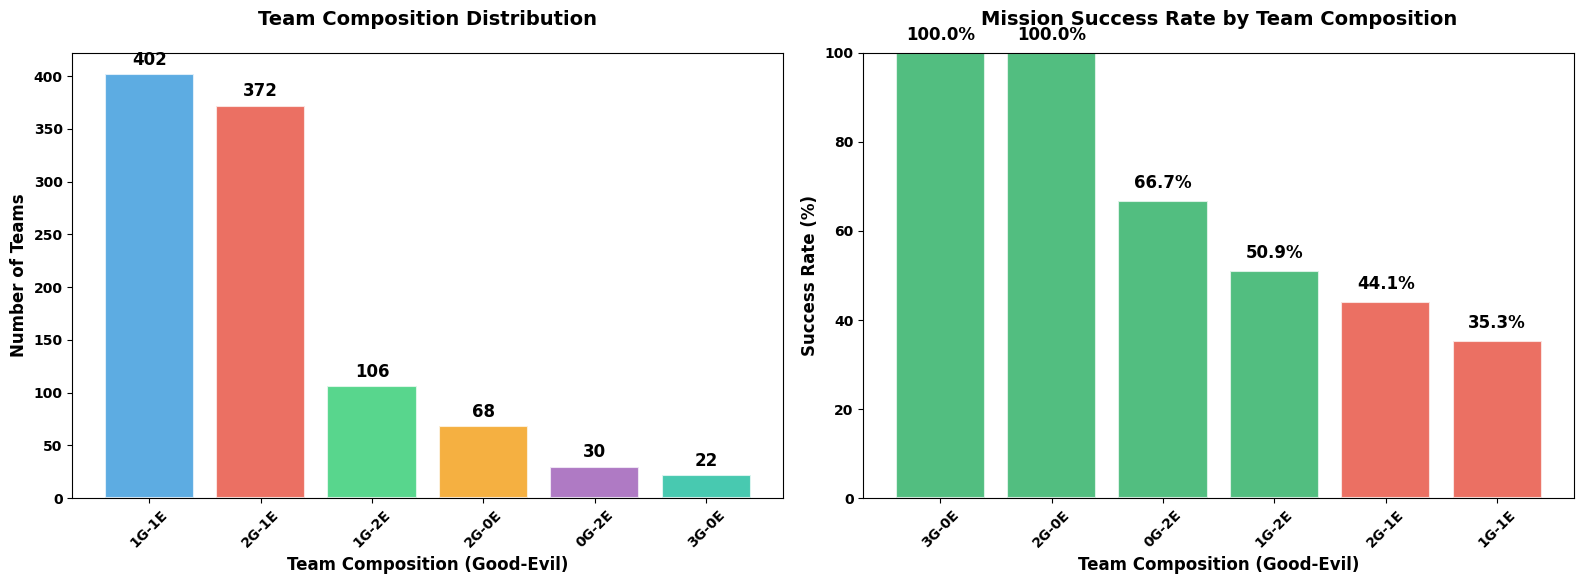

📊 Team Composition Bar Chart Analysis:
Total teams analyzed: 1000

Composition distribution:
composition_type
1G-1E    402
2G-1E    372
1G-2E    106
2G-0E     68
0G-2E     30
3G-0E     22
Name: count, dtype: int64

Success rates by composition:
composition_type
3G-0E    100.0
2G-0E    100.0
0G-2E     66.7
1G-2E     50.9
2G-1E     44.1
1G-1E     35.3
Name: outcome, dtype: float64


In [68]:
# Team Composition Bar Chart Analysis
def create_team_composition_bar_chart():
    """Generate team composition distribution using bar charts with outcome analysis"""
    
    # Extract team composition data
    composition_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        roles_str = row.get('player_roles', '{}')
        
        # Parse roles
        try:
            roles = json.loads(roles_str.replace('""', '"').strip('"'))
        except:
            continue
            
        # Extract team members
        team_match = re.search(r"Team: (.+?)(?:\n|$)", public_history)
        if not team_match:
            continue
            
        team_members = [p.strip() for p in team_match.group(1).split(',')]
        
        # Extract outcome
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        outcome = outcome_match.group(1) if outcome_match else 'Unknown'
        
        # Analyze team composition
        team_roles = [roles.get(p, 'Unknown') for p in team_members]
        good_count = team_roles.count('Good')
        evil_count = team_roles.count('Evil')
        
        composition_data.append({
            'good_count': good_count,
            'evil_count': evil_count,
            'outcome': outcome,
            'composition_type': f"{good_count}G-{evil_count}E"
        })
    
    comp_df = pd.DataFrame(composition_data)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Composition distribution
    comp_counts = comp_df['composition_type'].value_counts()
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
    
    bars = ax1.bar(comp_counts.index, comp_counts.values, color=colors[:len(comp_counts)], 
                   alpha=0.8, edgecolor='white', linewidth=1.5)
    ax1.set_title('Team Composition Distribution', fontweight='bold', fontsize=14, pad=20)
    ax1.set_xlabel('Team Composition (Good-Evil)', fontweight='bold')
    ax1.set_ylabel('Number of Teams', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Success rate by composition
    comp_success = comp_df.groupby('composition_type')['outcome'].apply(
        lambda x: (x == 'PASS').mean() * 100
    ).sort_values(ascending=False)
    
    bars2 = ax2.bar(comp_success.index, comp_success.values, 
                    color=['#27ae60' if x > 50 else '#e74c3c' for x in comp_success.values],
                    alpha=0.8, edgecolor='white', linewidth=1.5)
    ax2.set_title('Mission Success Rate by Team Composition', fontweight='bold', fontsize=14, pad=20)
    ax2.set_xlabel('Team Composition (Good-Evil)', fontweight='bold')
    ax2.set_ylabel('Success Rate (%)', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 100)
    
    # Add percentage labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('fig/team_composition_bar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Team Composition Bar Chart Analysis:")
    print(f"Total teams analyzed: {len(comp_df)}")
    print("\nComposition distribution:")
    print(comp_counts)
    print("\nSuccess rates by composition:")
    print(comp_success.round(1))

# Generate team composition bar chart
if len(augmented_df) > 0:
    create_team_composition_bar_chart()
else:
    print("⚠️ No augmented data available for visualization")

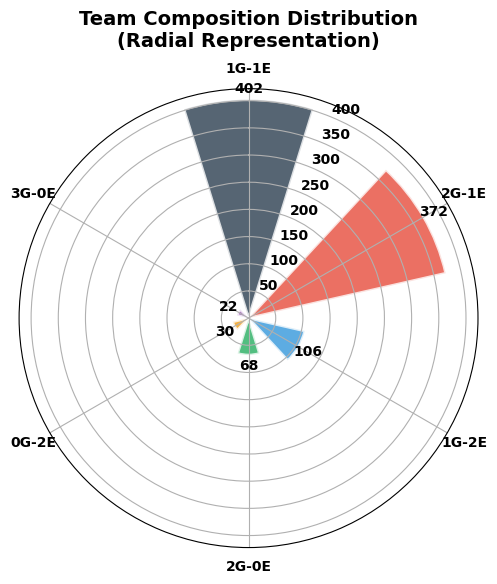

📊 Team Composition Radial Analysis:
Total teams analyzed: 1000

Radial distribution:
composition_type
1G-1E    402
2G-1E    372
1G-2E    106
2G-0E     68
0G-2E     30
3G-0E     22
Name: count, dtype: int64


In [44]:
# Team Composition Radial Chart
def create_team_composition_radial():
    """Generate team composition distribution using radial/polar visualization"""
    
    # Extract team composition data
    composition_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        roles_str = row.get('player_roles', '{}')
        
        # Parse roles
        try:
            roles = json.loads(roles_str.replace('""', '"').strip('"'))
        except:
            continue
            
        # Extract team members
        team_match = re.search(r"Team: (.+?)(?:\n|$)", public_history)
        if not team_match:
            continue
            
        team_members = [p.strip() for p in team_match.group(1).split(',')]
        
        # Analyze team composition
        team_roles = [roles.get(p, 'Unknown') for p in team_members]
        good_count = team_roles.count('Good')
        evil_count = team_roles.count('Evil')
        
        composition_data.append({
            'composition_type': f"{good_count}G-{evil_count}E"
        })
    
    comp_df = pd.DataFrame(composition_data)
    
    # Create polar plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw=dict(projection='polar'))
    
    comp_counts = comp_df['composition_type'].value_counts()
    angles = np.linspace(0, 2*np.pi, len(comp_counts), endpoint=False)
    
    # Colors with better contrast
    colors = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#f39c12', '#9b59b6']
    
    bars = ax.bar(angles, comp_counts.values, width=0.6, alpha=0.8, 
                  color=colors[:len(comp_counts)], edgecolor='white', linewidth=2)
    
    ax.set_title('Team Composition Distribution\n(Radial Representation)', 
                 fontweight='bold', fontsize=14, pad=30)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles), comp_counts.index, fontweight='bold')
    
    # Add value labels
    for angle, count, bar in zip(angles, comp_counts.values, bars):
        height = bar.get_height()
        ax.text(angle, height + max(comp_counts.values) * 0.05, str(count),
                ha='center', va='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('fig/team_composition_radial.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Team Composition Radial Analysis:")
    print(f"Total teams analyzed: {len(comp_df)}")
    print("\nRadial distribution:")
    print(comp_counts)

# Generate team composition radial chart
if len(augmented_df) > 0:
    create_team_composition_radial()
else:
    print("⚠️ No augmented data available for visualization")

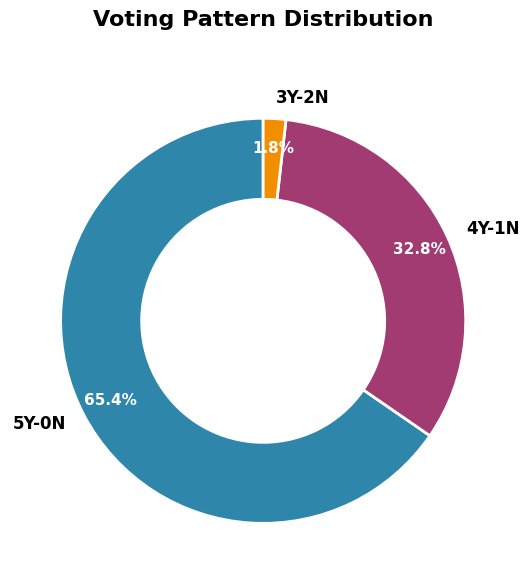

📊 Voting Pattern Distribution (Updated):
Total votes analyzed: 1000

Pattern distribution:
vote_pattern
5Y-0N    654
4Y-1N    328
3Y-2N     18
Name: count, dtype: int64


In [63]:
# Updated Voting Pattern Distribution with Center Percentages
def create_voting_pattern_distribution_updated():
    """Generate voting pattern distribution with percentages in the center"""
    
    # Extract voting data
    voting_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        
        # Extract votes
        votes_match = re.search(r"Votes: (.+?)(?:\n|$)", public_history)
        if not votes_match:
            continue
            
        votes_str = votes_match.group(1)
        votes = {}
        for vote_pair in votes_str.split():
            if ':' in vote_pair:
                player, vote = vote_pair.split(':')
                votes[player] = vote
        
        yes_count = sum(1 for v in votes.values() if v == 'Y')
        no_count = sum(1 for v in votes.values() if v == 'N')
        
        voting_data.append({
            'vote_pattern': f"{yes_count}Y-{no_count}N"
        })
    
    vote_df = pd.DataFrame(voting_data)
    pattern_counts = vote_df['vote_pattern'].value_counts()
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Improved color palette - elegant and professional
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # Create donut chart with percentages in center
    wedges, texts, autotexts = ax.pie(pattern_counts.values, labels=pattern_counts.index, 
                                     autopct='', colors=colors, startangle=90,
                                     wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
                                     pctdistance=0.7)
    
    # Style text elements
    for text in texts:
        text.set_fontweight('bold')
        text.set_fontsize(12)
    
    # Add percentages in the middle of each segment
    for i, (wedge, count) in enumerate(zip(wedges, pattern_counts.values)):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = 0.85 * np.cos(np.radians(angle))  # Move further out into the segment
        y = 0.85 * np.sin(np.radians(angle))
        percentage = (count / pattern_counts.sum()) * 100
        ax.text(x, y, f'{percentage:.1f}%', ha='center', va='center', 
                fontweight='bold', fontsize=11, color='white')
        
    ax.set_title('Voting Pattern Distribution', fontweight='bold', fontsize=16, pad=30)
    
    plt.tight_layout()
    plt.savefig('fig/voting_pattern_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Voting Pattern Distribution (Updated):")
    print(f"Total votes analyzed: {len(vote_df)}")
    print("\nPattern distribution:")
    print(pattern_counts)

# Generate updated voting pattern distribution
if len(augmented_df) > 0:
    create_voting_pattern_distribution_updated()
else:
    print("⚠️ No augmented data available for visualization")

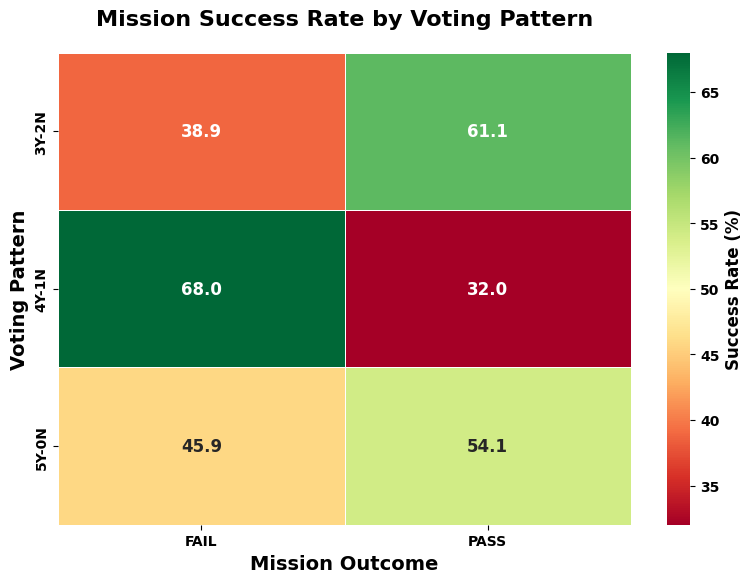

📊 Voting Success Rate Analysis:
Success rate by voting pattern:
outcome       FAIL  PASS
vote_pattern            
3Y-2N         38.9  61.1
4Y-1N         68.0  32.0
5Y-0N         45.9  54.1


In [46]:
# Mission Success Rate by Voting Pattern
def create_voting_success_analysis():
    """Generate mission success rate analysis by voting patterns"""
    
    # Extract voting data with outcomes
    voting_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        
        # Extract votes
        votes_match = re.search(r"Votes: (.+?)(?:\n|$)", public_history)
        if not votes_match:
            continue
            
        votes_str = votes_match.group(1)
        votes = {}
        for vote_pair in votes_str.split():
            if ':' in vote_pair:
                player, vote = vote_pair.split(':')
                votes[player] = vote
        
        # Extract outcome
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        outcome = outcome_match.group(1) if outcome_match else 'Unknown'
        
        yes_count = sum(1 for v in votes.values() if v == 'Y')
        no_count = sum(1 for v in votes.values() if v == 'N')
        
        voting_data.append({
            'vote_pattern': f"{yes_count}Y-{no_count}N",
            'outcome': outcome
        })
    
    vote_df = pd.DataFrame(voting_data)
    
    # Create crosstab for success rates
    vote_outcome_crosstab = pd.crosstab(vote_df['vote_pattern'], vote_df['outcome'], normalize='index') * 100
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Create heatmap with custom colormap
    sns.heatmap(vote_outcome_crosstab, annot=True, cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'Percentage (%)'}, fmt='.1f',
                linewidths=0.5, linecolor='white')
    
    ax.set_title('Mission Success Rate by Voting Pattern', fontweight='bold', fontsize=16, pad=20)
    ax.set_xlabel('Mission Outcome', fontweight='bold', fontsize=14)
    ax.set_ylabel('Voting Pattern', fontweight='bold', fontsize=14)
    
    # Style the colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Success Rate (%)', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('fig/voting_success_rate.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Voting Success Rate Analysis:")
    print("Success rate by voting pattern:")
    print(vote_outcome_crosstab.round(1))

# Generate voting success rate analysis
if len(augmented_df) > 0:
    create_voting_success_analysis()
else:
    print("⚠️ No augmented data available for visualization")

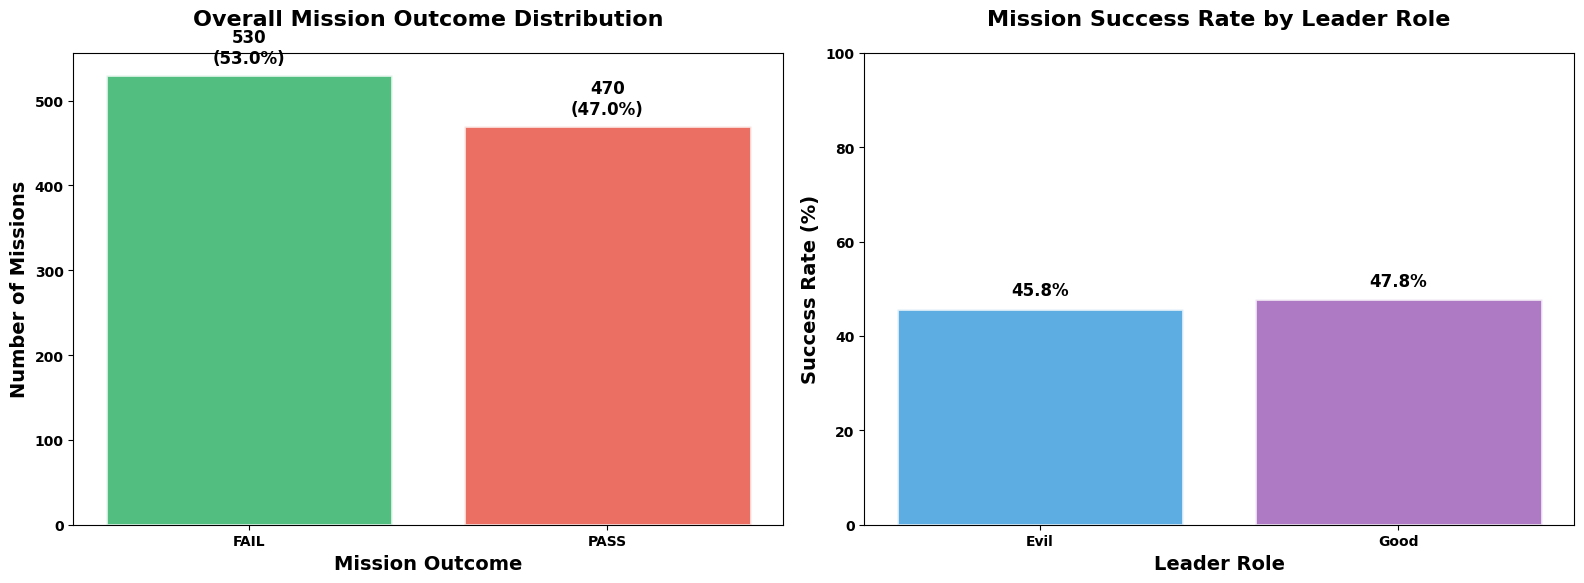

📊 Mission Outcome Distribution:
Total missions: 1000
Overall success rate: 0.470

Outcome distribution:
outcome
FAIL    530
PASS    470
Name: count, dtype: int64

Success rate by leader role:
leader_role
Evil    45.8
Good    47.8
Name: outcome, dtype: float64


In [47]:
# Mission Outcome Distribution
def create_mission_outcome_distribution():
    """Generate overall mission outcome distribution with scenario analysis"""
    
    # Extract mission data
    mission_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        roles_str = row.get('player_roles', '{}')
        
        # Parse roles
        try:
            roles = json.loads(roles_str.replace('""', '"').strip('"'))
        except:
            continue
        
        # Extract data
        leader_match = re.search(r"Leader: (P\d)", public_history)
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        
        if not all([leader_match, outcome_match]):
            continue
            
        leader = leader_match.group(1)
        outcome = outcome_match.group(1)
        leader_role = roles.get(leader, 'Unknown')
        
        mission_data.append({
            'leader_role': leader_role,
            'outcome': outcome
        })
    
    mission_df = pd.DataFrame(mission_data)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Overall outcome distribution
    outcome_counts = mission_df['outcome'].value_counts()
    colors = ['#27ae60', '#e74c3c']  # Success green, failure red
    
    bars = ax1.bar(outcome_counts.index, outcome_counts.values, color=colors, 
                   alpha=0.8, edgecolor='white', linewidth=2)
    
    ax1.set_title('Overall Mission Outcome Distribution', fontweight='bold', fontsize=16, pad=20)
    ax1.set_xlabel('Mission Outcome', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Number of Missions', fontweight='bold', fontsize=14)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{int(height)}\n({height/sum(outcome_counts.values)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # 2. Success rate by leader role
    leader_success = mission_df.groupby('leader_role')['outcome'].apply(
        lambda x: (x == 'PASS').mean() * 100
    )
    
    bars2 = ax2.bar(leader_success.index, leader_success.values,
                    color=['#3498db', '#9b59b6'], alpha=0.8, edgecolor='white', linewidth=2)
    
    ax2.set_title('Mission Success Rate by Leader Role', fontweight='bold', fontsize=16, pad=20)
    ax2.set_xlabel('Leader Role', fontweight='bold', fontsize=14)
    ax2.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=14)
    ax2.set_ylim(0, 100)
    
    # Add percentage labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('fig/mission_outcome_bar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Mission Outcome Distribution:")
    print(f"Total missions: {len(mission_df)}")
    print(f"Overall success rate: {(mission_df['outcome'] == 'PASS').mean():.3f}")
    print("\nOutcome distribution:")
    print(outcome_counts)
    print("\nSuccess rate by leader role:")
    print(leader_success.round(1))

# Generate mission outcome distribution
if len(augmented_df) > 0:
    create_mission_outcome_distribution()
else:
    print("⚠️ No augmented data available for visualization")

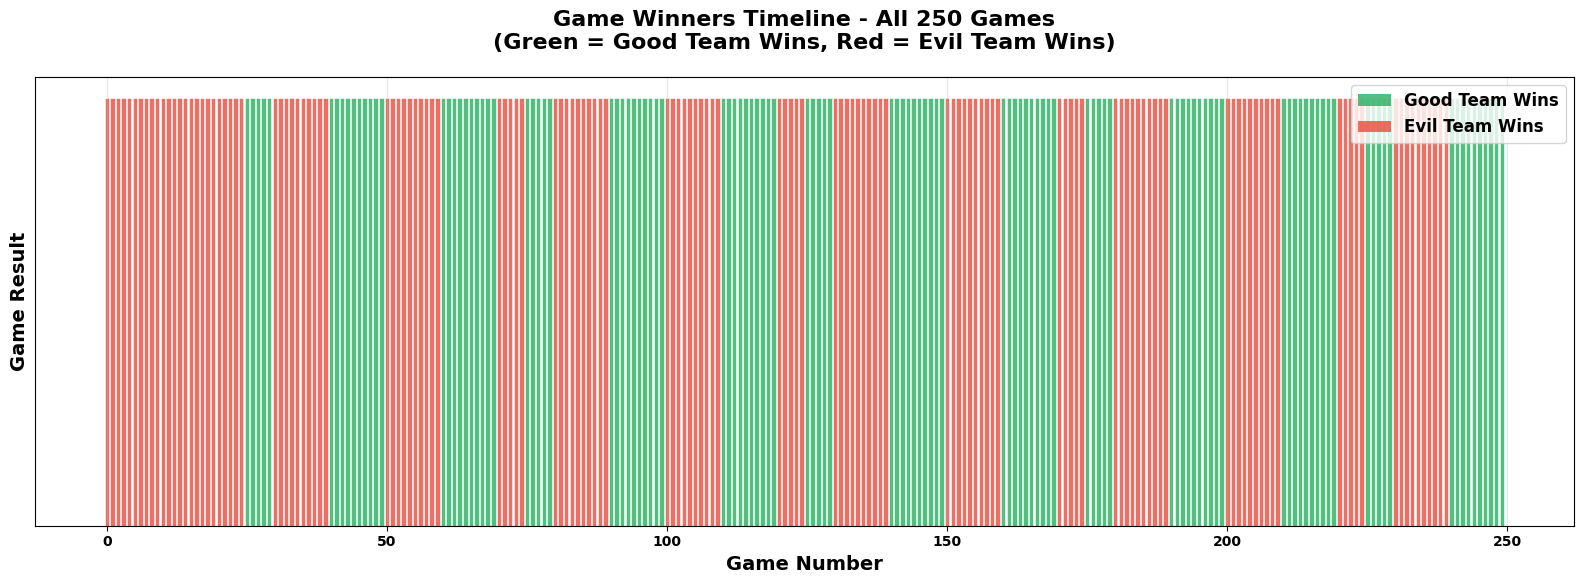

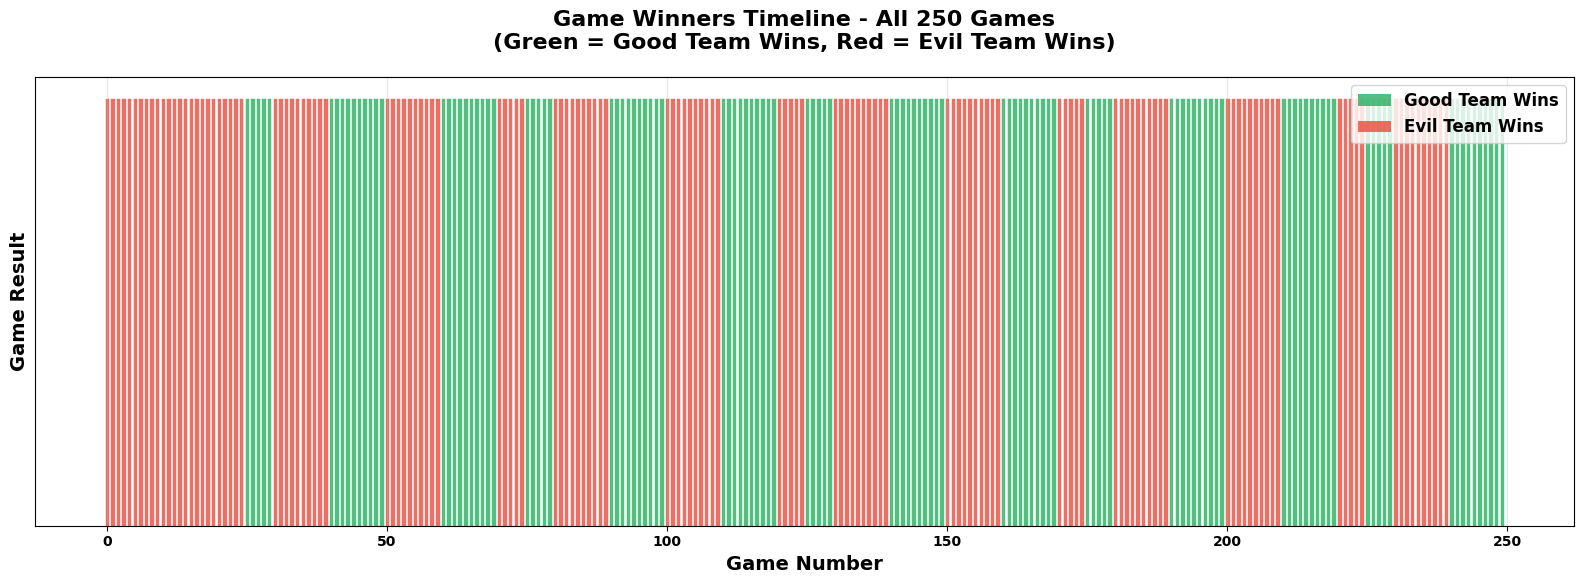

📊 Game Winners Timeline:
Total games: 250
Good Team wins: 115
Evil Team wins: 135




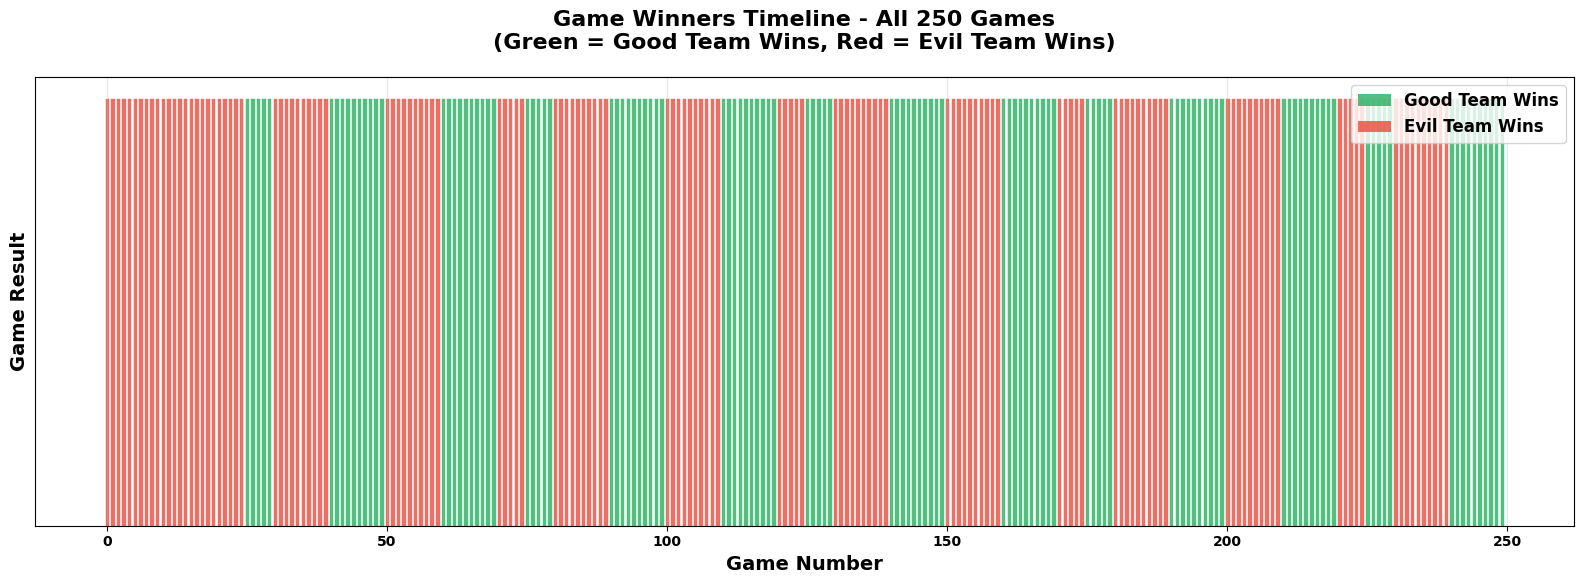

📊 Game Winners Timeline:
Total games: 250
Good Team wins: 115
Evil Team wins: 135




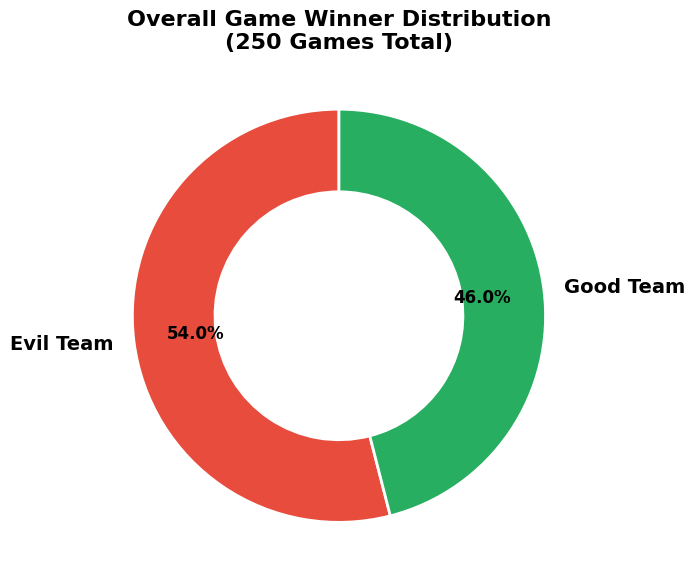

📊 Game Winner Distribution:
Total games analyzed: 250
winner
Evil Team    135
Good Team    115
Name: count, dtype: int64
Good Team win rate: 46.0%
Evil Team win rate: 54.0%


In [66]:
# Game Winners Timeline - Individual Game Results
def create_game_winners_timeline():
    """Show who won each of the 250 games across the timeline"""
    
    # Group missions by game_id to determine game winners
    game_results = {}
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        game_id = row.get('game_id', '')
        
        # Extract outcome
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        if not outcome_match or not game_id:
            continue
            
        outcome = outcome_match.group(1)
        
        if game_id not in game_results:
            game_results[game_id] = []
        game_results[game_id].append(outcome)
    
    # Determine game winners
    game_data = []
    for game_id, outcomes in game_results.items():
        game_num = int(game_id[1:]) if game_id.startswith('G') else 0
        pass_count = outcomes.count('PASS')
        fail_count = outcomes.count('FAIL')
        
        if pass_count >= 3:
            winner = 'Good Team'
        elif fail_count >= 3:
            winner = 'Evil Team'
        else:
            winner = 'Incomplete'
        
        game_data.append({
            'game_id': game_id,
            'game_number': game_num,
            'winner': winner,
            'pass_count': pass_count,
            'fail_count': fail_count
        })
    
    game_df = pd.DataFrame(game_data).sort_values('game_number')
    
    # Create timeline visualization
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    
    colors = ['#27ae60' if winner == 'Good Team' else '#e74c3c' for winner in game_df['winner']]
    bars = ax.bar(range(len(game_df)), [1] * len(game_df), color=colors, 
                  alpha=0.8, edgecolor='white', linewidth=0.5)
    
    ax.set_title('Game Winners Timeline - All 250 Games\n(Green = Good Team Wins, Red = Evil Team Wins)', 
                 fontweight='bold', fontsize=16, pad=20)
    ax.set_xlabel('Game Number', fontweight='bold', fontsize=14)
    ax.set_ylabel('Game Result', fontweight='bold', fontsize=14)
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add legend
    from matplotlib.patches import Rectangle
    legend_elements = [Rectangle((0,0),1,1, facecolor='#27ae60', alpha=0.8, label='Good Team Wins'),
                      Rectangle((0,0),1,1, facecolor='#e74c3c', alpha=0.8, label='Evil Team Wins')]
    ax.legend(handles=legend_elements, fontsize=12)
    
    plt.tight_layout()
    plt.savefig('fig/game_winners_timeline.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    winner_counts = game_df['winner'].value_counts()
    print("📊 Game Winners Timeline:")
    print(f"Total games: {len(game_df)}")
    print(f"Good Team wins: {winner_counts.get('Good Team', 0)}")
    print(f"Evil Team wins: {winner_counts.get('Evil Team', 0)}")
    
    return game_df

# Game Winner Distribution Summary
def create_game_winner_distribution():
    """Show overall distribution of game winners"""
    
    # Get game data from previous function or recalculate
    game_results = {}
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        game_id = row.get('game_id', '')
        
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        if not outcome_match or not game_id:
            continue
            
        outcome = outcome_match.group(1)
        
        if game_id not in game_results:
            game_results[game_id] = []
        game_results[game_id].append(outcome)
    
    game_data = []
    for game_id, outcomes in game_results.items():
        pass_count = outcomes.count('PASS')
        fail_count = outcomes.count('FAIL')
        
        if pass_count >= 3:
            winner = 'Good Team'
        elif fail_count >= 3:
            winner = 'Evil Team'
        else:
            winner = 'Incomplete'
        
        game_data.append({'winner': winner})
    
    game_df = pd.DataFrame(game_data)
    winner_counts = game_df['winner'].value_counts()
    
    # Create donut chart
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    colors_pie = ['#e74c3c', '#27ae60']  # Evil first (red), Good second (green)
    
    wedges, texts, autotexts = ax.pie(winner_counts.values, labels=winner_counts.index,
                                     autopct='', colors=colors_pie, startangle=90,
                                     wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
                                     pctdistance=0.7)
    
    # Style text elements
    for text in texts:
        text.set_fontweight('bold')
        text.set_fontsize(14)
    
    # Add percentages in the center
    for i, (wedge, count) in enumerate(zip(wedges, winner_counts.values)):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = 0.7 * np.cos(np.radians(angle))
        y = 0.7 * np.sin(np.radians(angle))
        percentage = (count / winner_counts.sum()) * 100
        ax.text(x, y, f'{percentage:.1f}%', ha='center', va='center', 
                fontweight='bold', fontsize=12, color='black')
    
    ax.set_title('Overall Game Winner Distribution\n(250 Games Total)', 
                 fontweight='bold', fontsize=16)
    
    plt.tight_layout()
    plt.savefig('fig/game_winner_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Game Winner Distribution:")
    print(f"Total games analyzed: {len(game_df)}")
    print(winner_counts)
    print(f"Good Team win rate: {(winner_counts.get('Good Team', 0) / len(game_df) * 100):.1f}%")
    print(f"Evil Team win rate: {(winner_counts.get('Evil Team', 0) / len(game_df) * 100):.1f}%")

# Generate game winner visualizations separately
if len(augmented_df) > 0:
    create_game_winners_timeline()
    print("\n" + "="*50 + "\n")
    create_game_winner_distribution()
else:
    print("⚠️ No augmented data available for visualization")

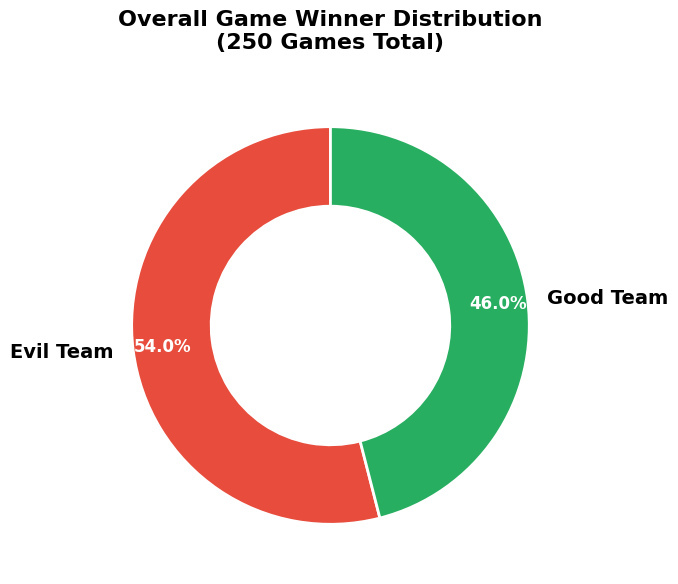

📊 Game Winner Distribution (Final):
Total games analyzed: 250
winner
Evil Team    135
Good Team    115
Name: count, dtype: int64
Good Team win rate: 46.0%
Evil Team win rate: 54.0%


In [65]:
# Updated Game Winner Distribution with Better Center Percentages
def create_game_winner_distribution_final():
    """Show overall distribution of game winners with percentages properly centered"""
    
    # Get game data
    game_results = {}
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        game_id = row.get('game_id', '')
        
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        if not outcome_match or not game_id:
            continue
            
        outcome = outcome_match.group(1)
        
        if game_id not in game_results:
            game_results[game_id] = []
        game_results[game_id].append(outcome)
    
    game_data = []
    for game_id, outcomes in game_results.items():
        pass_count = outcomes.count('PASS')
        fail_count = outcomes.count('FAIL')
        
        if pass_count >= 3:
            winner = 'Good Team'
        elif fail_count >= 3:
            winner = 'Evil Team'
        else:
            winner = 'Incomplete'
        
        game_data.append({'winner': winner})
    
    game_df = pd.DataFrame(game_data)
    winner_counts = game_df['winner'].value_counts()
    
    # Create donut chart
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    colors_pie = ['#e74c3c', '#27ae60']  # Evil first (red), Good second (green)
    
    wedges, texts, autotexts = ax.pie(winner_counts.values, labels=winner_counts.index,
                                     autopct='', colors=colors_pie, startangle=90,
                                     wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
                                     pctdistance=0.7)
    
    # Style text elements
    for text in texts:
        text.set_fontweight('bold')
        text.set_fontsize(14)
    
    # Add percentages in the middle of each segment (better positioning)
    for i, (wedge, count) in enumerate(zip(wedges, winner_counts.values)):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = 0.85 * np.cos(np.radians(angle))  # Move further out into the segment
        y = 0.85 * np.sin(np.radians(angle))
        percentage = (count / winner_counts.sum()) * 100
        ax.text(x, y, f'{percentage:.1f}%', ha='center', va='center', 
                fontweight='bold', fontsize=12, color='white')
    
    ax.set_title('Overall Game Winner Distribution\n(250 Games Total)', 
                 fontweight='bold', fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.savefig('fig/game_winner_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Game Winner Distribution (Final):")
    print(f"Total games analyzed: {len(game_df)}")
    print(winner_counts)
    print(f"Good Team win rate: {(winner_counts.get('Good Team', 0) / len(game_df) * 100):.1f}%")
    print(f"Evil Team win rate: {(winner_counts.get('Evil Team', 0) / len(game_df) * 100):.1f}%")

# Generate final game winner distribution
if len(augmented_df) > 0:
    create_game_winner_distribution_final()
else:
    print("⚠️ No augmented data available for visualization")

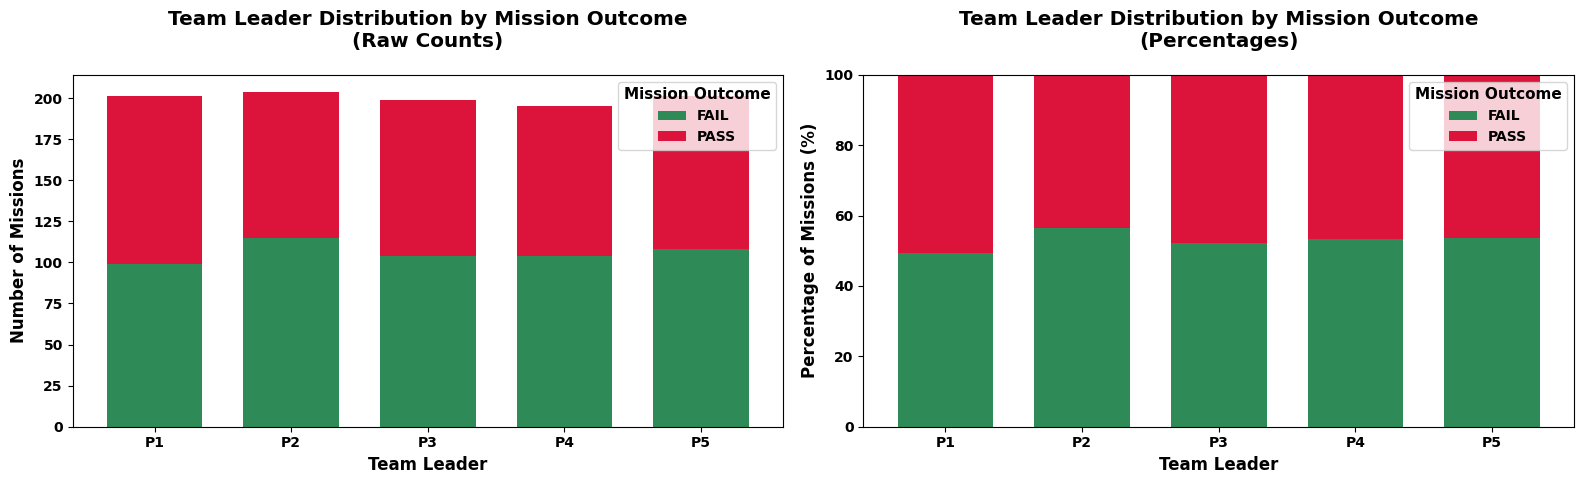

📊 Team Leader Distribution Analysis:
Total missions analyzed: 1000

Raw counts:
outcome  FAIL  PASS
leader             
P1         99   102
P2        115    89
P3        104    95
P4        104    91
P5        108    93

Percentages:
outcome  FAIL  PASS
leader             
P1       49.3  50.7
P2       56.4  43.6
P3       52.3  47.7
P4       53.3  46.7
P5       53.7  46.3


In [35]:
# 1. Team Leader Distribution Analysis
def create_team_leader_distribution():
    """Create stacked bar chart showing team leader vs mission outcome distribution"""
    
    # Extract data for analysis
    leader_outcome_data = []
    for _, row in augmented_df.iterrows():
        public_history = row.get('public_history', '')
        
        # Extract leader
        leader_match = re.search(r"Leader: (P\d)", public_history)
        leader = leader_match.group(1) if leader_match else 'Unknown'
        
        # Extract outcome
        outcome_match = re.search(r"Quest \d+ Outcome: (PASS|FAIL)", public_history)
        outcome = outcome_match.group(1) if outcome_match else 'Unknown'
        
        leader_outcome_data.append({'leader': leader, 'outcome': outcome})
    
    # Create DataFrame for analysis
    leader_df = pd.DataFrame(leader_outcome_data)
    leader_counts = leader_df.groupby(['leader', 'outcome']).size().unstack(fill_value=0)
    
    # Calculate percentages
    leader_percentages = leader_counts.div(leader_counts.sum(axis=1), axis=0) * 100
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Raw counts
    leader_counts.plot(kind='bar', stacked=True, ax=ax1, 
                      color=['#2E8B57', '#DC143C'], width=0.7)
    ax1.set_title('Team Leader Distribution by Mission Outcome\n(Raw Counts)', fontweight='bold', pad=20)
    ax1.set_xlabel('Team Leader', fontweight='bold')
    ax1.set_ylabel('Number of Missions', fontweight='bold')
    ax1.legend(title='Mission Outcome', title_fontsize=11, fontsize=10)
    ax1.tick_params(axis='x', rotation=0)
    
    # Percentages
    leader_percentages.plot(kind='bar', stacked=True, ax=ax2,
                           color=['#2E8B57', '#DC143C'], width=0.7)
    ax2.set_title('Team Leader Distribution by Mission Outcome\n(Percentages)', fontweight='bold', pad=20)
    ax2.set_xlabel('Team Leader', fontweight='bold')
    ax2.set_ylabel('Percentage of Missions (%)', fontweight='bold')
    ax2.legend(title='Mission Outcome', title_fontsize=11, fontsize=10)
    ax2.tick_params(axis='x', rotation=0)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('fig/team_leader_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📊 Team Leader Distribution Analysis:")
    print(f"Total missions analyzed: {len(leader_df)}")
    print("\nRaw counts:")
    print(leader_counts)
    print("\nPercentages:")
    print(leader_percentages.round(1))

# Generate team leader distribution
if len(augmented_df) > 0:
    create_team_leader_distribution()
else:
    print("⚠️ No augmented data available for visualization")

We developed a constraint satisfaction framework to generate authentic multi-round Avalon game histories by expanding 250 seed games into ~1000 rows with predetermined outcome sequences. Our approach uses role-aware team selection logic where Good leaders strategically test suspicious players on FAIL missions whereas Evil leaders maintain cover by avoiding highly suspicious teammates, combined with a dynamic suspicion scoring system that evolves based on mission outcomes (+1.0 for failures, -0.3 for successes). The constraint satisfaction is achieved through ground truth role knowledge enabling leaders to naturally select teams that satisfy target outcomes without appearing artificial, while strategic voting mechanisms ensure realistic behavioral patterns and proposal passage.

Implementation Approach for the Verifier
For 1000 samples across 250 games (~4 rows/game), I recommend a comprehensive single-pass verification:

Processing Strategy
1. Load & Group - Read entire CSV, group by game_id, sort by round_id within each game
2. Parse Public History - For each game, extract structured data (leader, team, votes, outcome) from each round's public_history text
3. Apply Validation Rules - Run all checks sequentially per game, collecting violations with context
4. Generate Flagged Report - Output games with hard violations + separate list of soft violations for manual review

Hard Violations (Impossible Game States)
These indicate data corruption or generation errors:

- Leader rotation broken - Leader sequence doesn't follow P1→P2→P3→P4→P5→P1 pattern
- Wrong team size - Team doesn't match required size for that round (R1:2, R2:3, R3:2, R4:3, R5:3)
- Leader not in team - The round's leader is not a member of their proposed team
- Invalid game length - Game has <3 or >5 rounds
- Wrong termination - Game ends without exactly 3 PASS or 3 FAIL outcomes
- Quest number mismatch - "Quest N Outcome" where N doesn't equal round_id
- Invalid player IDs - Team/leader contains players other than P1-P5
- Malformed public_history - Missing required fields or unparseable format

Soft Violations (Flag for Manual Review)
Unusual but potentially valid patterns:

- Both failed players in next team - Both members of a failed quest reappear together in immediate next round (except R5 desperation)
- Repeated team composition - Identical team in consecutive rounds despite different outcomes
- All-good or all-evil team - Based on player_roles, team has no representation from one alignment (unusual strategy)